In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset/training_set.npz
/kaggle/input/models/CNN.keras


In [2]:
cd /kaggle/input/dataset/

/kaggle/input/dataset


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


seed = 42

np.random.seed(seed)

tf.random.set_seed(seed);

# 1 - Load data

In [5]:
data = np.load('training_set.npz')

X = data['images']

y = data['labels']

In [6]:
labels = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}

In [7]:
# Duplicates count and removal
import hashlib

image_hashes = [hashlib.md5(img.tobytes()).hexdigest() for img in X]
df = pd.DataFrame({'image_hash': image_hashes, 'label': y.flatten()})
unique_df = df.drop_duplicates(subset='image_hash').reset_index(drop=True)

# Manual duplicates check
'''
# Count duplicates by grouping by label and hash
duplicate_counts = (
    unique_df[unique_df.duplicated(subset=['image_hash'], keep=False)]
    .groupby('label')
    .size()
)

# Display the counts
print("Duplicate Counts per Label:")
print(duplicate_counts)
'''

X_unique  = X[unique_df.index]
y_unique = y[unique_df.index]
print(f'Labels reduced from {len(y)} to {len(y_unique)}')
# (should output a reduction from 13759 to 11953)

Labels reduced from 13759 to 11953


In [8]:
X = X_unique
y = y_unique

In [9]:
# Convert images to grayscale
def rgb2gray(rgb):
    return np.dot(rgb[..., :3], [0.2989, 0.5870, 0.1140])

In [10]:
X_gray = rgb2gray(X)

# Reshape to add the channel dimension (1 for grayscale)
X_gray = X_gray.reshape(X_gray.shape + (1,))

#X = X_gray

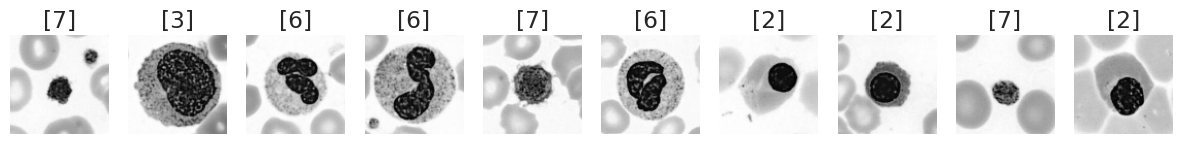

In [11]:
# Visualize some grayscale images
def visualize_images(images, titles, n=5):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].reshape(images[i].shape[:2]), cmap='gray')
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Display some grayscale images from the training set
nb = 10
visualize_images(X_gray[:nb], y[:nb], nb)

In [12]:
X.shape

(11953, 96, 96, 3)

# 2 - Split data for training, validation, and testing 

In [13]:
# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train)


#X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=0.9, stratify=y_train)
#X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=0.9, stratify=y_train)



# Normalize pixel values
X_train, X_val = X_train / 255.0, X_val / 255.0


# 3 - Handle unbalanced classes

In [14]:
# Compute class weights
# Flatten y_train
y_train, y_val = y_train.flatten(), y_val.flatten()
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(enumerate(class_weights))

In [15]:
class_weights_dict

{0: 1.7640682656826567,
 1: 0.6805160142348754,
 2: 1.3856884057971015,
 3: 0.7349154496541123,
 4: 1.804009433962264,
 5: 1.5104660347551342,
 6: 0.6386940547762191,
 7: 0.9097288296860133}

# 4 - Data augmentation

In [16]:
# Define data augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest',
    #brightness_range=[0.8, 1.2],
    preprocessing_function=lambda x: tf.image.random_brightness(x, max_delta=0.2)
)
datagen.fit(X_train)

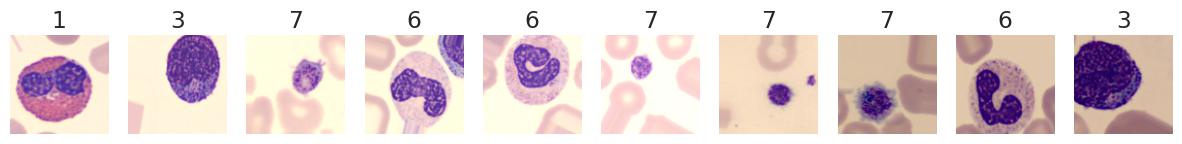

In [17]:
# Visualize some augmented images
def visualize_augmented_images(datagen, images, titles, n=5):
    plt.figure(figsize=(15, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        augmented_images = datagen.flow(images[i].reshape(1, 96, 96, 3), batch_size=1)
        augmented_image = next(augmented_images)[0].reshape(96, 96, 3)
        plt.imshow(augmented_image)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Display some augmented images from the training set
nb = 10
visualize_augmented_images(datagen, X_train[:nb], y_train[:nb], nb)

# 5 - Build model

In [18]:
X_train.shape

(7649, 96, 96, 3)

In [19]:
model = Sequential([
    Conv2D(32, (3, 3), activation='elu', input_shape=X_train.shape[1:4], kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='elu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='elu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), activation='elu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='elu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(8, activation='softmax')  # Change to 8 output units for 8 classes
])

# 6 - Compile the model

In [20]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 7 - Train the model with early stopping

In [21]:
# Load the saved model
model = tf.keras.models.load_model('/kaggle/input/models/CNN.keras')

In [22]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    #X_train,
    #y_train,
    validation_data=(X_val, y_val),
    epochs=33,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

# Save the trained model to a file with the accuracy included in the filename
model_filename = '/kaggle/working/CNN'+'.keras'
model.save(model_filename)

# Delete the model to free up resources
del model

Epoch 1/33


I0000 00:00:1731269362.555829     167 service.cc:145] XLA service 0x7e124c016c60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731269362.555887     167 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  3/240 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.9618 - loss: 0.2747 

I0000 00:00:1731269372.519010     167 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_8', 4 bytes spill stores, 12 bytes spill loads

I0000 00:00:1731269372.536422     167 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 26/240 ━━━━━━━━━━━━━━━━━━━━ 1:38 462ms/step - accuracy: 0.9570 - loss: 0.3102

I0000 00:00:1731269383.918158     170 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'loop_add_subtract_fusion_4', 4 bytes spill stores, 12 bytes spill loads



240/240 ━━━━━━━━━━━━━━━━━━━━ 57s 180ms/step - accuracy: 0.9544 - loss: 0.3080 - val_accuracy: 0.9639 - val_loss: 0.2816 - learning_rate: 2.5000e-04
Epoch 2/33
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.9563 - loss: 0.3212 - val_accuracy: 0.9556 - val_loss: 0.3003 - learning_rate: 2.5000e-04
Epoch 3/33
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.9539 - loss: 0.3257 - val_accuracy: 0.8369 - val_loss: 0.6623 - learning_rate: 2.5000e-04
Epoch 4/33
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.9572 - loss: 0.3063 - val_accuracy: 0.9624 - val_loss: 0.2797 - learning_rate: 2.5000e-04
Epoch 5/33
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - accuracy: 0.9502 - loss: 0.3252 - val_accuracy: 0.8646 - val_loss: 0.6039 - learning_rate: 2.5000e-04
Epoch 6/33
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - accuracy: 0.9558 - loss: 0.2975 - val_accuracy: 0.9331 - val_loss: 0.3451 - learning_rate: 2.5000e-04
Epoch 7/33
240/240 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - 

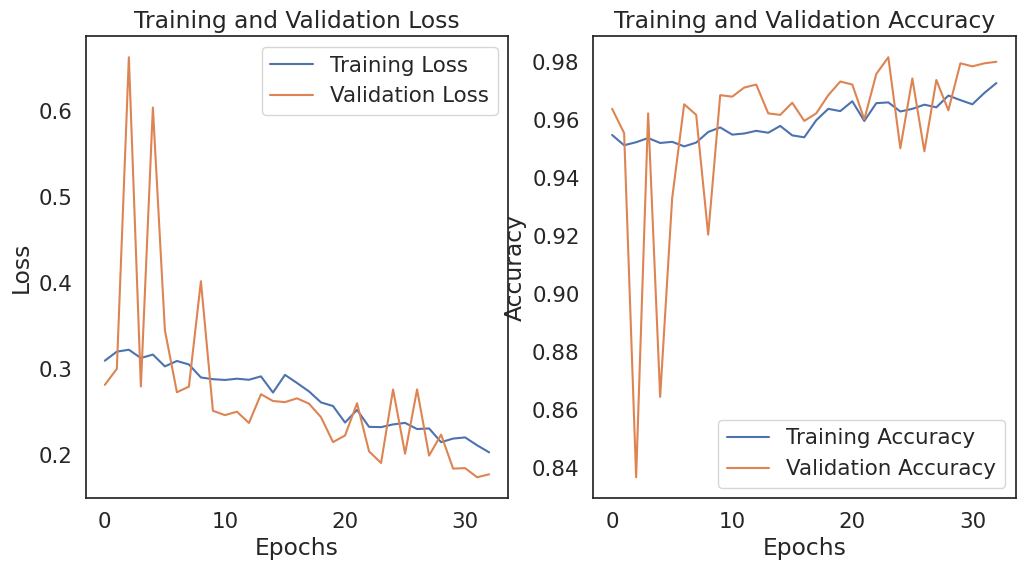

In [23]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 8 - Evaluate the model

In [24]:
cd /kaggle/working

/kaggle/working


In [25]:
# Load the saved model
model = tf.keras.models.load_model(model_filename)

# Display a summary of the model architecture
model.summary(expand_nested=True, show_trainable=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d (Conv2D)             │ (None, 94, 94, 32)    │        896 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 94, 94, 32)    │        128 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d               │ (None, 47, 47, 32)    │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 47, 47, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_1 (Conv2D)           │ (None, 45, 45, 64)    │     18,496 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_1       │ (None, 45, 45, 64)    │        256 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d_1             │ (None, 22, 22, 64)    │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 22, 22, 64)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 20, 20, 128)   │     73,856 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_2       │ (None, 20, 20, 128)   │        512 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d_2             │ (None, 10, 10, 128)   │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 10, 10, 128)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 8, 8, 256)     │    295,168 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_3       │ (None, 8, 8, 256)     │      1,024 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ max_pooling2d_3             │ (None, 4, 4, 256)     │          0 │   -   │
│ (MaxPooling2D)              │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 4, 4, 256)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 128)           │    524,416 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_4       │ (None, 128)           │        512 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_4 (Dropout)         │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼─────

 Total params: 2,746,458 (10.48 MB)

 Trainable params: 915,080 (3.49 MB)

 Non-trainable params: 1,216 (4.75 KB)

 Optimizer params: 1,830,162 (6.98 MB)

In [26]:
# Preprocess competition data
X_test = X_test / 255.0
true_classes = y_test.flatten()

In [27]:
# Predict labels for the entire test set
predictions = model.predict(X_test, verbose=0)

# Display the shape of the predictions
print("Predictions Shape:", predictions.shape)

Predictions Shape: (2391, 8)


Accuracy score over the test set: 0.9787
Precision score over the test set: 0.9789
Recall score over the test set: 0.9787
F1 score over the test set: 0.9787


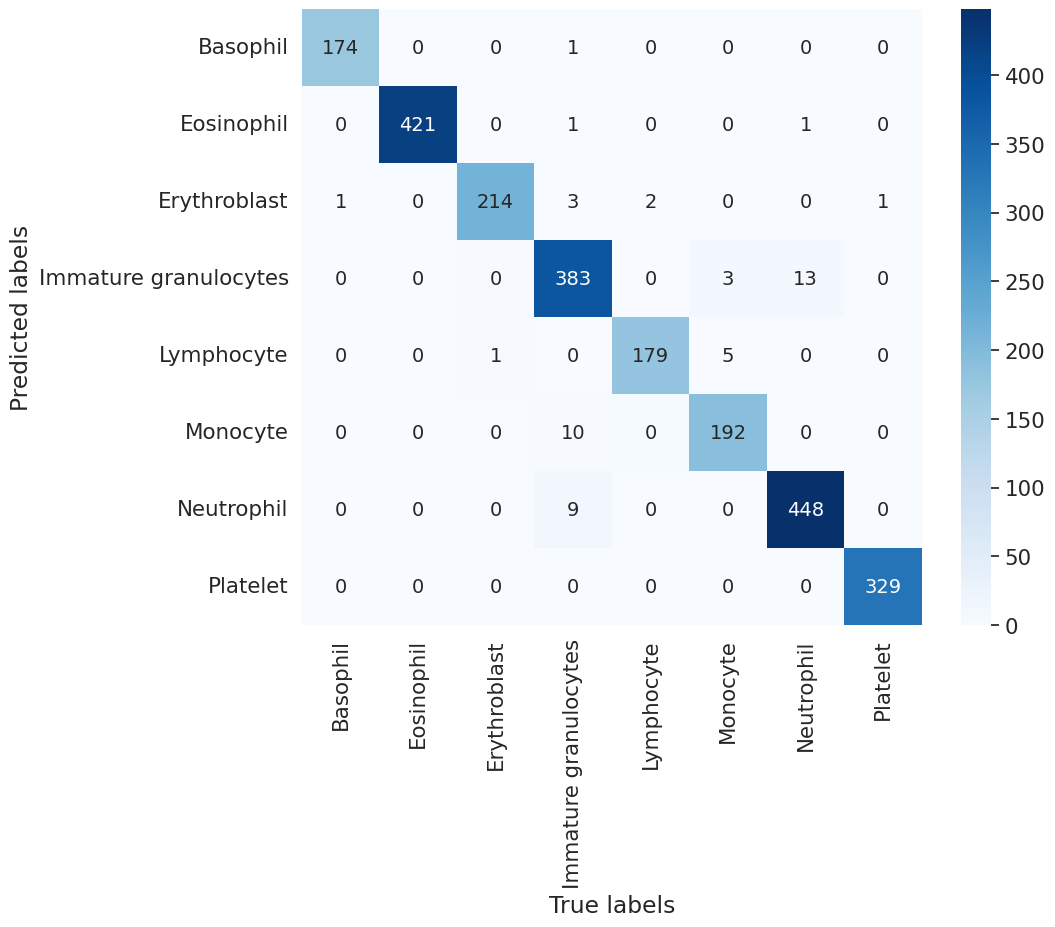

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

pred_classes = np.argmax(predictions, axis=-1)

# Calculate and display test set accuracy
accuracy = accuracy_score(true_classes, pred_classes)
print(f'Accuracy score over the test set: {round(accuracy, 4)}')

# Calculate and display test set precision
precision = precision_score(true_classes, pred_classes, average='weighted')
print(f'Precision score over the test set: {round(precision, 4)}')

# Calculate and display test set recall
recall = recall_score(true_classes, pred_classes, average='weighted')
print(f'Recall score over the test set: {round(recall, 4)}')

# Calculate and display test set F1 score
f1 = f1_score(true_classes, pred_classes, average='weighted')
print(f'F1 score over the test set: {round(f1, 4)}')

# Compute the confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Combine numbers and percentages into a single string for annotation
annot = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm.T, annot=annot, fmt='', xticklabels=list(labels.values()), yticklabels=list(labels.values()), cmap='Blues')
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()